In [98]:
### IMPORTS ###
import sys
sys.path.append('../')

import autolib
import fom
import Optimisation.opt as opt
import pathlib
#from pathlib import PosixPath
#user_home_path = PosixPath('~/')
#user_home_path_full = user_home_path.expanduser()


#final_speed = 20.
num_cores = 200
maxtime = 1440
#runID = "Fasympmonochrome_fixgaussian20_50GW_nG30"
runID = "Fasymp4_fixgaussian20_50GW" # _nG30"

student = "Grating_Entire"  # Change this to your name or preferred folder name

# common_path = user_home_path_full / "Library/CloudStorage/OneDrive-TheUniversityofSydney(Students)/Doppler Damping - Jadon Lin/Documentation/Data/relativistic-lightsail-dynamics/Optimisation/Jadon's results"
# custom_folder_path = f"Fasymp/final_speed{int(final_speed)}/maxtime{int(maxtime)}/{runID}"
# custom_folder_path = f"Fasymp/mono/maxtime{int(maxtime)}/{runID}"

filepath = "Z:\\Github\\relativistic-lightsail-dynamics\\Optimisation\\run_parallel_extract.ipynb"
filepath = "combine_extract.ipynb"
current_dir = pathlib.Path(filepath).resolve(strict=True).parent
fname_preamble = current_dir / "Data" / student

# fname_preamble = common_path / custom_folder_path

# import pathlib
# fname_preamble = pathlib.Path("./Data")

pkl_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}'
txt_fname = fname_preamble / f'{runID}_FOM_optimisation_maxtime{maxtime}_curated.txt'

maxima_and_maximisers_sorted, opt_gratings_sorted, _ = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=0)

Total function evaluations: 663204
Average function evaluations per core: 3316


In [99]:
def print_grating_params(grating):
    print(f"grating_pitch   = {grating.params[0]}")
    print(f"grating_depth   = {grating.params[1]}")
    print(f"box1_width      = {grating.params[2]}")
    print(f"box2_width      = {grating.params[3]}")
    print(f"box_centre_dist = {grating.params[4]}")
    print(f"box1_eps        = {grating.params[5]}")
    print(f"box2_eps        = {grating.params[6]}")
    print(f"gaussian_width  = {grating.params[7]}")
    print(f"substrate_depth = {grating.params[8]}")
    print(f"substrate_eps   = {grating.params[9]}")

In [100]:
import numpy as np
from scipy.optimize import minimize
from parameters import D1_ND

def get_final(l_min, l_max):
    doppler = l_min / l_max

    def test(v):
        v = v/100
        return np.abs(doppler - D1_ND(v))

    sol = minimize(test, 5)
    final_speed = sol.x[0]
    return final_speed

In [101]:
import numpy as np
import os
os.environ["OMP_NUM_THREADS"] = "1" 
os.environ["OPENBLAS_NUM_THREADS"] = "1" 
os.environ["MKL_NUM_THREADS"] = "1" 
os.environ["VECLIB_MAXIMUM_THREADS"] = "1" 
os.environ["NUMEXPR_NUM_THREADS"] = "1" 

import parameters
from parameters import D1_ND

from twobox import TwoBox

I0, L, m, c = parameters.Parameters()
optimum_number = 3

final_speed = get_final(1., 1.05)

wavelength_range = [1,1/D1_ND([final_speed/100,0])]
#wavelength_range = [0.99999,1.0000004]
#bandwidth = wavelength_range[1] - wavelength_range[0]
#relative_bandwidth = bandwidth / wavelength_range[0]
#wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

grating1 = grating

[1, np.float64(1.049999999971945)]
Total function evaluations: 663204
Average function evaluations per core: 3316
TORCWA
[tensor(1.6413, dtype=torch.float64), tensor(0.3851, dtype=torch.float64), tensor(0.3264, dtype=torch.float64), tensor(0.0466, dtype=torch.float64), tensor(0.7099, dtype=torch.float64), tensor(5.9552, dtype=torch.float64), tensor(10.3013, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(0.4197, dtype=torch.float64), tensor(4.5667, dtype=torch.float64)]
[tensor(1.6413, dtype=torch.float64), tensor(0.3851, dtype=torch.float64), tensor(0.3264, dtype=torch.float64), tensor(0.0466, dtype=torch.float64), tensor(0.7099, dtype=torch.float64), tensor(5.9552, dtype=torch.float64), tensor(10.3013, dtype=torch.float64), tensor(0.4197, dtype=torch.float64), tensor(4.5667, dtype=torch.float64)]
0.00011725140238450422
grating_pitch   = 1.641273897979067
grating_depth   = 0.385134391078635
box1_width      = 0.3264483817296625
box2_width      = 0.04658598095748553
box_c

In [102]:
I0, L, m, c = parameters.Parameters()
optimum_number = 6

final_speed = get_final(1., 1.05)

wavelength_range = [1,1/D1_ND([final_speed/100,0])]
#wavelength_range = [0.99999,1.0000004]
#bandwidth = wavelength_range[1] - wavelength_range[0]
#relative_bandwidth = bandwidth / wavelength_range[0]
#wavelength_range = [0.99999 - 10.*relative_bandwidth, 1.0000004 + 10.*relative_bandwidth]
print(wavelength_range)
_, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=optimum_number)
optimisation_RCWA_engine = opt_grating.RCWA_engine
print(optimisation_RCWA_engine)

# Test optimum FOM convergence by rebuilding the grating with higher fidelity
match optimisation_RCWA_engine:
    case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
        opt_params = [p._value for p in opt_grating.all_params]
    case _:
        opt_params = opt_grating.all_params
print(opt_params)
print(opt_grating.params)
grating = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)    

print(fom.multifom(grating, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
# print(fom.multifom(grating_converged, monofom=fom.monofom_asymp, final_speed=final_speed, goal=0.1, return_grad=False))
print(f"grating_pitch   = {grating.params[0]}")
print(f"grating_depth   = {grating.params[1]}")
print(f"box1_width      = {grating.params[2]}")
print(f"box2_width      = {grating.params[3]}")
print(f"box_centre_dist = {grating.params[4]}")
print(f"box1_eps        = {grating.params[5]}")
print(f"box2_eps        = {grating.params[6]}")
print(f"gaussian_width  = {grating.params[7]}")
print(f"substrate_depth = {grating.params[8]}")
print(f"substrate_eps   = {grating.params[9]}")
print(f"\nFoM recorded:     {maxima_and_maximisers_sorted[optimum_number][0]}")

grating2 = grating

[1, np.float64(1.049999999971945)]
Total function evaluations: 663204
Average function evaluations per core: 3316
TORCWA
[tensor(1.6397, dtype=torch.float64), tensor(0.4443, dtype=torch.float64), tensor(0.3406, dtype=torch.float64), tensor(0.0511, dtype=torch.float64), tensor(0.7078, dtype=torch.float64), tensor(5.8748, dtype=torch.float64), tensor(10.4545, dtype=torch.float64), tensor(20., dtype=torch.float64), tensor(0.5843, dtype=torch.float64), tensor(4.5571, dtype=torch.float64)]
[tensor(1.6397, dtype=torch.float64), tensor(0.4443, dtype=torch.float64), tensor(0.3406, dtype=torch.float64), tensor(0.0511, dtype=torch.float64), tensor(0.7078, dtype=torch.float64), tensor(5.8748, dtype=torch.float64), tensor(10.4545, dtype=torch.float64), tensor(0.5843, dtype=torch.float64), tensor(4.5571, dtype=torch.float64)]
0.00010308432310784945
grating_pitch   = 1.6396761254348513
grating_depth   = 0.44432874487544616
box1_width      = 0.34055202066710755
box2_width      = 0.05110622337224755
b

In [ ]:
num_plot_points = 200

wavelengths = np.linspace(*wavelength_range, num_plot_points)
init_wavelength = 1.
eigvals = grating.npa.zeros((4,num_plot_points), dtype=np.complex128)

for idx, lam in enumerate(wavelengths):
    # Calculate eigs for each order
    grating1.wavelength = grating1.npa.array(lam)
    grating2.wavelength = grating2.npa.array(lam)
    
    stiffnesses = fom.force_coeff(grating1,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J1 = grating.npa.concatenate((grating1.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    stiffnesses = fom.force_coeff(grating2,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

    J2 = grating2.npa.concatenate((grating2.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

    eigvals[:,idx] = grating.npa.eigvals((J1+ J2)/2)
    
grating1.wavelength = init_wavelength
grating2.wavelength = init_wavelength
eigvals

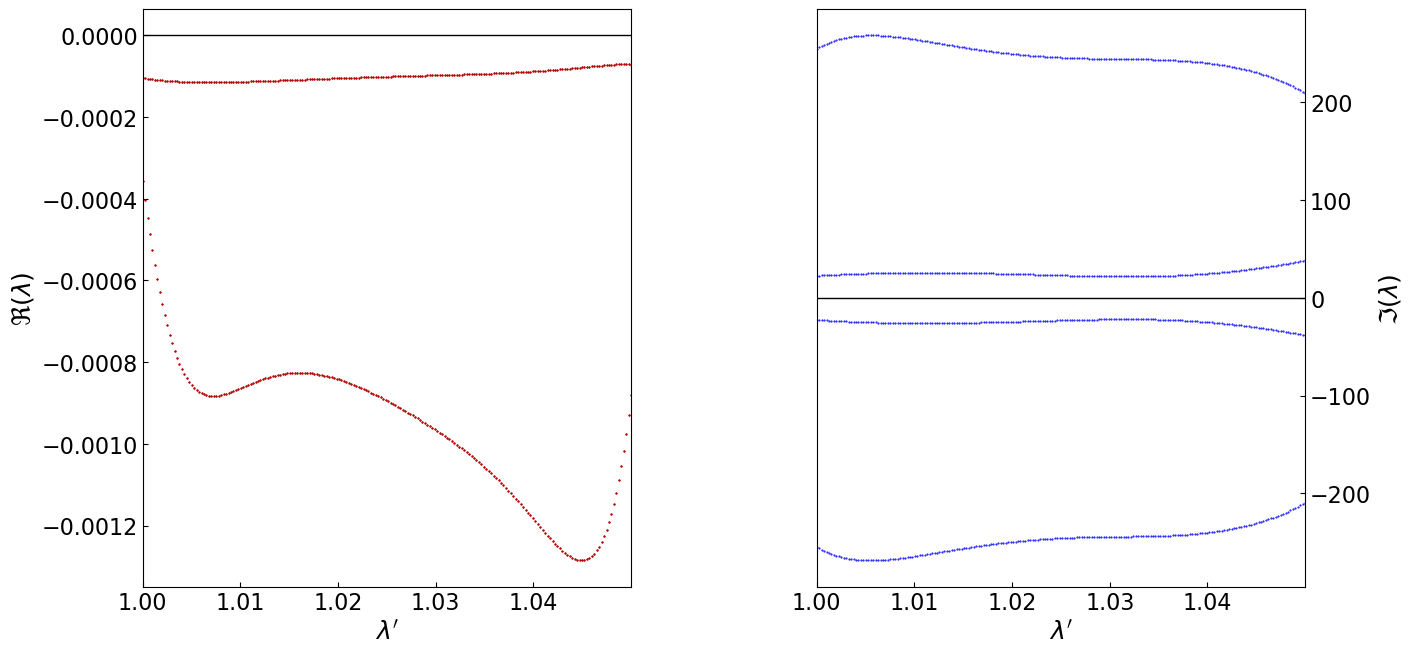

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, dummy, ax2) = plt.subplots(nrows=1, ncols=3, width_ratios=(1,0.1,1))
dummy.axis('off')
p = grating.to_numpy(grating.grating_pitch)
ax1.set_xlim(np.array(wavelength_range)) # normalise to grating pitch
ax2.set_xlim(np.array(wavelength_range)) # normalise to grating pitch
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

ax1.axhline(y=0, color='black', linestyle='-', lw = '1')
ax1.tick_params(axis='both', which='both', direction='in')  # ticks inside box
# ax1.tick_params(axis='y', color=colorReal, labelcolor=colorReal)  # colored ticks
ax1.set_ylabel(ylabel=rf"$\Re(\lambda)$")  #color=colorReal  # colored y label
ax1.set(xlabel=r"$\lambda'$")

ax2.axhline(y=0, color='black', linestyle='-', lw = '1')
ax2.tick_params(axis='both', which='both', direction='in')  # ticks inside box
# ax2.tick_params(axis='y', color = colorImag, labelcolor=colorImag)  # colored ticks
ax2.set_ylabel(ylabel=rf"$\Im(\lambda)$")  #color=colorImag  # colored y label
ax2.set(xlabel=r"$\lambda'$")

marker = 'o'

colorReal = (0.7, 0, 0)
colorImag = 'blue'
for i in range(4):            
    ax1.plot(wavelengths,np.real(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorReal, fillstyle='full',  color=colorReal)
    ax2.plot(wavelengths,np.imag(grating.to_numpy(eigvals[i,:])), marker, markersize=0.5, markerfacecolor=colorImag, fillstyle='full',  color=colorImag)

#ax1.set_xlim((0.610, 0.640))
#ax2.set_xlim((0.610, 0.640))
#ax1.set_ylim((-0.004, 0.001))

In [6]:
I0, L, m, c = parameters.Parameters()
#optimum_number = np.arange(0,50)

final_speed = get_final(1., 1.05)

#FoM_array = []

wavelength_range = [1,1/D1_ND([final_speed/100,0])]

num_plot_points = 200

wavelengths = np.linspace(*wavelength_range, num_plot_points)

averages = np.zeros((50, 50))
minimums = np.zeros((50, 50))




for i in range(0, 50):
    _, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=i)
    optimisation_RCWA_engine = opt_grating.RCWA_engine

    match optimisation_RCWA_engine:
        case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
            opt_params = [p._value for p in opt_grating.all_params]
        case _:
            opt_params = opt_grating.all_params

    grating1 = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)
    #grating_converged = TwoBox(*opt_params, wavelength=1., angle=0., Nx=1000, nG=100, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

    averages[i, i] = maxima_and_maximisers_sorted[i][0]
    minimums[i, i] = maxima_and_maximisers_sorted[i][0]

    for j in range(i + 1, 30):
        _, _, opt_grating = opt.extract_opt(pkl_fname, num_processes=num_cores, output_opt_idx=j)
        optimisation_RCWA_engine = opt_grating.RCWA_engine

        match optimisation_RCWA_engine:
            case "GRCWA":  # GRCWA opt params are saved as autograd ArrayBoxes, have to get values manually
                opt_params = [p._value for p in opt_grating.all_params]
            case _:
                opt_params = opt_grating.all_params

        grating2 = TwoBox(*opt_params, wavelength=1., angle=0., Nx=opt_grating.Nx, nG=opt_grating.nG, Qabs=np.inf, RCWA_engine=opt_grating.RCWA_engine, torcwa_edge_sharpness=opt_grating.torcwa_edge_sharpness)

        final_speed = get_final(1., 1.05)

        init_wavelength = 1.
        eigvals = grating.npa.zeros((4,num_plot_points), dtype=np.complex128)

        for idx, lam in enumerate(wavelengths):
            # Calculate eigs for each order
            grating1.wavelength = grating1.npa.array(lam)
            grating2.wavelength = grating2.npa.array(lam)
            
            stiffnesses = fom.force_coeff(grating1,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

            J1 = grating.npa.concatenate((grating1.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

            stiffnesses = fom.force_coeff(grating2,I0,m,c,grad_method="finite",out="mat",normalise=False) # to get jacobian/matrix

            J2 = grating2.npa.concatenate((grating2.npa.array([[0,0,1,0],[0,0,0,1]]), stiffnesses))

            eigvals[:,idx] = grating.npa.eigvals((J1+ J2)/2)
            
        grating1.wavelength = init_wavelength
        grating2.wavelength = init_wavelength

        eigReal = grating.npa.real(eigvals)
        fom_combined = grating.npa.min(-eigReal, axis = 0)[0]
        average_fom = fom_combined.mean().detach().numpy()
        min_fom = grating.npa.min(-eigReal).detach().numpy()
        print(i, j, average_fom, min_fom)

        averages[i, j] = average_fom
        minimums[i, j] = min_fom

np.savetxt("averages.txt", averages)
np.savetxt("minimums.txt", minimums)

        

Total function evaluations: 663204
Average function evaluations per core: 3316
Total function evaluations: 663204
Average function evaluations per core: 3316
0 1 0.00013474617086607187 8.822651747205073e-05
Total function evaluations: 663204
Average function evaluations per core: 3316
0 2 0.00012763130849340973 8.285884936515449e-05
Total function evaluations: 663204
Average function evaluations per core: 3316
0 3 0.00013242460521636088 2.777370362118392e-05
Total function evaluations: 663204
Average function evaluations per core: 3316
0 4 0.00012174768200957726 8.513321602390996e-05
Total function evaluations: 663204
Average function evaluations per core: 3316
0 5 0.00011825878713424596 8.603205340605366e-05
Total function evaluations: 663204
Average function evaluations per core: 3316
0 6 0.00011968573127459733 0.00010267090268999742
Total function evaluations: 663204
Average function evaluations per core: 3316
0 7 0.00012729467685428697 1.381053490314213e-05
Total function evaluatio

In [3]:
import numpy as np

fom_averaged = np.loadtxt("averages.txt")
fom_minimums = np.loadtxt("minimums.txt")

fom_minimums = fom_minimums[:30, :30]
fom_averaged = fom_averaged[:30, :30]

In [24]:
fom_averaged[3, 6]

np.float64(0.000122589399308959)

In [25]:
fom_averaged[3, 3], fom_averaged[6,6]

(np.float64(0.00011725140238546838), np.float64(0.00010308432311051749))

In [20]:
fom_averaged[:, 13].argmax()

np.int64(1)

In [10]:
fom_averaged[:30, :30][17, :].max()

np.float64(9.929873935197103e-05)

In [42]:
fom_minimums[:30, :30][:, 17]

array([ 1.01893494e-04,  4.20334979e-05,  1.00382324e-04, -1.72865795e-05,
        7.99794817e-05,  9.08596997e-05,  7.90347180e-05, -4.29964020e-05,
        5.24187246e-05,  9.10135152e-05,  8.46870526e-05,  6.47397580e-05,
        8.35526691e-05,  7.08978367e-05,  4.51090058e-05,  4.88338514e-05,
        8.19018603e-05,  9.21572068e-05,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00])

In [ ]:

total =  fom_averaged + fom_minimums
total[total == total.diagonal()] = 0
total[total == 0] = -np.inf
ind = total.argmax()

In [95]:
total.flatten()[ind], fom_averaged.flatten()[ind], fom_minimums.flatten()[ind]

(np.float64(0.00022693465958917037),
 np.float64(0.000122589399308959),
 np.float64(0.00010434526028021138))

In [96]:
np.indices(total.shape)[0].flatten()[ind]

np.int64(3)

In [97]:
np.indices(total.shape)[1].flatten()[ind]

np.int64(6)